# ALICE Analysis: YFV19, Ankylosing Spondylitis (AS), and MLR TCR-seq Datasets

This notebook runs a highly customized MIR implementation of ALICE (Antigen-specific Lymphocyte Identification by Clustering of Expanded sequences) on three benchmark datasets from `isalgo/airr_benchmark`. The implementation is inspired by ideas described in the ALICE paper and is not a literal line-by-line reimplementation of the original software.

- **YF (Yellow Fever vaccine)** - 6 donors x 2 time points (day 0, day 15) TRB repertoires.
- **AS (Ankylosing Spondylitis)** - 4 donors, synovial fluid CD8+ TRB repertoires.
- **MLR (Mixed Lymphocyte Reaction)** - 24 samples (fresh vs proliferating) from Adaptive immunoSEQ.

Reference:
Pogorelyy MV, Minervina AA, Touzel MP, et al. Detecting T cell receptors involved in immune responses from single repertoire snapshots. *PLoS Biol.* 2019;17(6):e3000314. doi:10.1371/journal.pbio.3000314. PMID:31194732.
PubMed: https://pubmed.ncbi.nlm.nih.gov/31194732/

**Runtime note:** This notebook uses `n_jobs=8` to accelerate compute-intensive ALICE stages with process-based parallel execution.

In [1]:
"""Cell 1: Environment setup, imports, and dataset download."""
import sys
import warnings
from pathlib import Path
from collections import defaultdict

import importlib.metadata
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
from IPython.display import display
from scipy.stats import mannwhitneyu

# Environment versions for reproducibility
print(f"Python {sys.version.split()[0]}")
for _pkg in ["mirpy-lib", "polars", "numpy", "pandas", "matplotlib", "scipy"]:
    try:
        print(f"  {_pkg}: {importlib.metadata.version(_pkg)}")
    except importlib.metadata.PackageNotFoundError:
        pass

repo_root = (
    Path.cwd().resolve().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd().resolve()
)
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))

from mir.biomarkers.alice import compute_alice
from mir.common.clonotype import Clonotype
from mir.common.filter import filter_functional
from mir.common.parser import AdaptiveParser, ClonotypeTableParser, load_vdjdb_latest
from mir.common.repertoire import LocusRepertoire, infer_locus
from mir.graph.edit_distance_graph import build_edit_distance_graph
from mir.utils.notebook_assets import ensure_airr_benchmark, ensure_airr_benchmark_alice

SEED = 42
np.random.seed(SEED)
N_JOBS = 8
FDR_THRESH = 0.05
# ALICE cluster member: n_neighbors >= N_MIN_NEIGHBORS (self always counted, so
# 2 = at least one real Hamming-1 neighbour) AND q_value < FDR_THRESH.
N_MIN_NEIGHBORS = 2
ALICE_PGEN_MODE = "exact"

# Publication-quality style (Nature/Science journal aesthetics)
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 10,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "axes.linewidth": 0.8,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "xtick.major.size": 3.5,
    "ytick.major.size": 3.5,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "axes.grid": False,
    "figure.figsize": (7, 5),
})

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

BENCHMARK_DIR_YF_AS = ensure_airr_benchmark_alice(repo_root=repo_root, subsets=["yf", "as"])
YF_DIR = BENCHMARK_DIR_YF_AS / "alice" / "yf"
AS_DIR = BENCHMARK_DIR_YF_AS / "alice" / "as"
BENCHMARK_DIR_MLR = ensure_airr_benchmark(repo_root=repo_root, allow_patterns=["alice/mlr/*"])
MLR_DIR = BENCHMARK_DIR_MLR / "alice" / "mlr"

print(f"\nYF_DIR  = {YF_DIR}  (exists: {YF_DIR.exists()})")
print(f"AS_DIR  = {AS_DIR}  (exists: {AS_DIR.exists()})")
print(f"MLR_DIR = {MLR_DIR}  (exists: {MLR_DIR.exists()})")


Python 3.12.12
  mirpy-lib: 1.0.0
  polars: 1.39.3
  numpy: 2.4.4
  pandas: 2.3.3
  matplotlib: 3.10.9
  scipy: 1.17.1


/Users/mikesh/vcs/mirpy/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Fetching 27 files: 100%|██████████| 27/27 [00:01<00:00, 25.30it/s]


YF_DIR  = /Users/mikesh/vcs/mirpy/notebooks/assets/large/airr_benchmark/alice/yf  (exists: True)
AS_DIR  = /Users/mikesh/vcs/mirpy/notebooks/assets/large/airr_benchmark/alice/as  (exists: True)
MLR_DIR = /Users/mikesh/vcs/mirpy/notebooks/assets/large/airr_benchmark/alice/mlr  (exists: True)


# Yellow Fever (YF) Dataset

## Parse YF samples

Files follow the MiXCR v2/v3 naming convention: `<donor>_d<day>.tsv.gz` (e.g. `P1_d0.tsv.gz`, `S2_d15.tsv.gz`).
`ClonotypeTableParser` auto-maps MiXCR column names and infers locus from the `j_gene` prefix.

In [2]:
"""Cell 2: Parse YF samples from MiXCR TSV.gz files and downsample to 10k duplicates."""
from mir.common.sampling import downsample

# YF donors in the benchmark dataset
YF_DONORS = ["P1", "P2", "Q1", "Q2", "S1", "S2"]
# Downsampled to 10k duplicate counts for notebook-speed runs (~2-5k unique CDR3s per sample).
# The benchmark suite tests larger subsamples (5k-25k clonotypes) for full-scale validation.
YF_DOWNSAMPLE_COUNT = 10_000

parser_yf = ClonotypeTableParser()
warnings.filterwarnings("ignore", category=FutureWarning)

def _parse_yf_filename(path: Path) -> tuple[str, int]:
    """Return (donor, day) from `<donor>_d<day>.tsv.gz`."""
    stem = path.name.replace(".tsv.gz", "").replace(".tsv", "")
    donor, day_part = stem.split("_d")
    return donor, int(day_part)

yf_samples: dict[tuple[str, int], LocusRepertoire] = {}

for fp in sorted(YF_DIR.glob("*.tsv.gz")):
    try:
        donor, day = _parse_yf_filename(fp)
    except ValueError:
        print(f"  Skipping unexpected filename: {fp.name}")
        continue

    clonotypes = parser_yf.parse(str(fp))
    trb = [c for c in clonotypes if c.locus == "TRB"]
    rep = filter_functional(LocusRepertoire(clonotypes=trb, locus="TRB", repertoire_id=fp.stem))
    rep = downsample(rep, YF_DOWNSAMPLE_COUNT, random_seed=SEED)
    yf_samples[(donor, day)] = rep
    print(f"  {fp.name}: {rep.clonotype_count:,} TRB clonotypes after downsample to {YF_DOWNSAMPLE_COUNT:,}")

print(f"\nLoaded {len(yf_samples)} YF samples")

  P1_d0.tsv.gz: 9,566 TRB clonotypes after downsample to 10,000
  P1_d15.tsv.gz: 9,395 TRB clonotypes after downsample to 10,000
  P2_d0.tsv.gz: 9,525 TRB clonotypes after downsample to 10,000
  P2_d15.tsv.gz: 9,423 TRB clonotypes after downsample to 10,000
  Q1_d0.tsv.gz: 6,891 TRB clonotypes after downsample to 10,000
  Q1_d15.tsv.gz: 8,100 TRB clonotypes after downsample to 10,000
  Q2_d0.tsv.gz: 8,301 TRB clonotypes after downsample to 10,000
  Q2_d15.tsv.gz: 8,081 TRB clonotypes after downsample to 10,000
  S1_d0.tsv.gz: 9,225 TRB clonotypes after downsample to 10,000
  S1_d15.tsv.gz: 9,319 TRB clonotypes after downsample to 10,000
  S2_d0.tsv.gz: 9,549 TRB clonotypes after downsample to 10,000
  S2_d15.tsv.gz: 9,334 TRB clonotypes after downsample to 10,000

Loaded 12 YF samples


## Run ALICE on YF samples

ALICE scores each clonotype by comparing its Hamming-1 neighbourhood size `n`
against the Poisson expectation `N * Pgen`, where `N` is the number of
clonotypes sharing the same V+J gene pair (`match_mode="vj"`).
Benjamini-Hochberg FDR is applied per sample.

**ALICE cluster member** = `n_neighbors ≥ 2` (at least one real Hamming-1 neighbour)
AND `q_value < 0.05`. Isolated sequences with pgen ≪ 1/N are Pgen-significant but not
convergent — the neighbourhood filter removes them.

In [3]:
"""Cell 3: Run ALICE on YF samples; collect cluster members."""

yf_alice_tables: dict[tuple[str, int], pd.DataFrame] = {}
yf_alice_rows = []

for (donor, day), rep in sorted(yf_samples.items()):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        result = compute_alice(
            rep,
            species="human",
            match_mode="vj",
            pgen_mode=ALICE_PGEN_MODE,
            as_table=True,
            n_jobs=N_JOBS,
        )

    tbl = result.table.to_pandas()
    yf_alice_tables[(donor, day)] = tbl
    # Cluster member: has ≥1 real Hamming-1 neighbour AND is BH-FDR significant
    hits = tbl[(tbl["n_neighbors"] >= N_MIN_NEIGHBORS) & (tbl["q_value"] < FDR_THRESH)].copy()

    yf_alice_rows.append({
        "Donor": donor,
        "Day": day,
        "Clonotypes": rep.clonotype_count,
        "ALICE clusters": len(hits),
        "Cluster %": 100 * len(hits) / max(1, rep.clonotype_count),
    })
    print(f"  {donor} day{day:>3}: {rep.clonotype_count:,} clonotypes → {len(hits)} ALICE cluster members")

df_yf_summary = pd.DataFrame(yf_alice_rows).sort_values(["Donor", "Day"]).reset_index(drop=True)
display(
    df_yf_summary.style
    .format({"Cluster %": "{:.1f}%", "Clonotypes": "{:,}", "ALICE clusters": "{:,}"})
    .background_gradient(subset=["ALICE clusters", "Cluster %"], cmap="YlOrRd")
    .set_caption("YF — ALICE cluster members per sample (n_neighbors ≥ 2, BH-FDR < 0.05)")
    .set_table_styles([{"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "10pt")]}])
)


  P1 day  0: 9,566 clonotypes → 217 ALICE cluster members
  P1 day 15: 9,395 clonotypes → 210 ALICE cluster members
  P2 day  0: 9,525 clonotypes → 214 ALICE cluster members
  P2 day 15: 9,423 clonotypes → 192 ALICE cluster members
  Q1 day  0: 6,891 clonotypes → 158 ALICE cluster members
  Q1 day 15: 8,100 clonotypes → 192 ALICE cluster members
  Q2 day  0: 8,301 clonotypes → 164 ALICE cluster members
  Q2 day 15: 8,081 clonotypes → 195 ALICE cluster members
  S1 day  0: 9,225 clonotypes → 194 ALICE cluster members
  S1 day 15: 9,319 clonotypes → 245 ALICE cluster members
  S2 day  0: 9,549 clonotypes → 233 ALICE cluster members
  S2 day 15: 9,334 clonotypes → 293 ALICE cluster members


,Donor,Day,Clonotypes,ALICE clusters,Cluster %
0,P1,0,"9,566",217,2.3%
1,P1,15,"9,395",210,2.2%
2,P2,0,"9,525",214,2.2%
3,P2,15,"9,423",192,2.0%
4,Q1,0,"6,891",158,2.3%
5,Q1,15,"8,100",192,2.4%
6,Q2,0,"8,301",164,2.0%
7,Q2,15,"8,081",195,2.4%
8,S1,0,"9,225",194,2.1%
9,S1,15,"9,319",245,2.6%


## YF Visualization

Paired bar chart comparing **ALICE cluster member fraction** (%) at day 0 and day 15
per donor. A day-15 increase is expected for HLA-A\*02 donors responding to LLWNGPMAV.

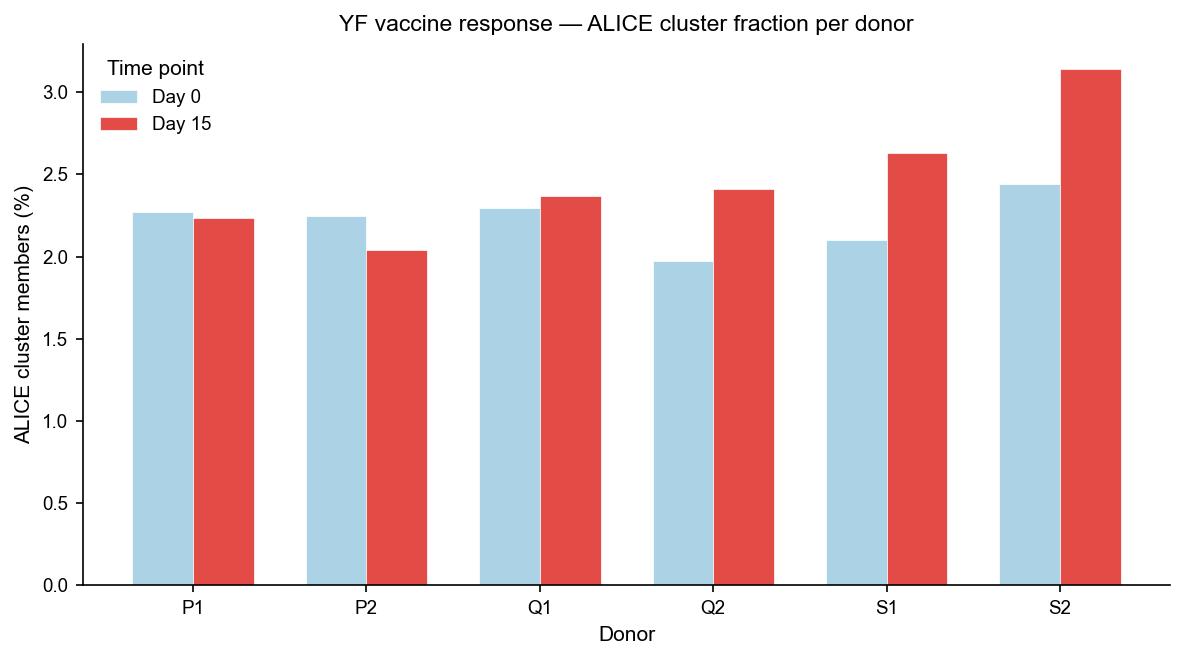

In [4]:
"""Cell 4: Paired bar chart — ALICE cluster fraction day 0 vs day 15 per donor."""

donors_ordered = sorted(df_yf_summary["Donor"].unique())
days_ordered = sorted(df_yf_summary["Day"].unique())
day_colors = {0: "#9ecae1", 15: "#de2d26"}
x = np.arange(len(donors_ordered))
bar_width = 0.35

fig, ax = plt.subplots(figsize=(8, 4.5))
for i, day in enumerate(days_ordered):
    sub = df_yf_summary[df_yf_summary["Day"] == day].set_index("Donor")
    heights = [sub.loc[d, "Cluster %"] if d in sub.index else 0.0 for d in donors_ordered]
    offset = (i - len(days_ordered) / 2 + 0.5) * bar_width
    ax.bar(
        x + offset, heights, bar_width,
        color=day_colors[day], label=f"Day {day}",
        alpha=0.85, edgecolor="white", linewidth=0.4,
    )

ax.set_xticks(x)
ax.set_xticklabels(donors_ordered)
ax.set_xlabel("Donor")
ax.set_ylabel("ALICE cluster members (%)")
ax.set_title("YF vaccine response — ALICE cluster fraction per donor")
ax.legend(title="Time point", frameon=False)
plt.tight_layout()
plt.savefig("yf_alice_cluster_fraction.pdf", bbox_inches="tight")
plt.show()


## VDJdb LLWNGPMAV / HLA-A\*02 overlap

ALICE cluster members are intersected with VDJdb TRB entries for LLWNGPMAV restricted to HLA-A\*02. Donors carrying HLA-A\*02 are expected to show a stronger day-15 signal because this epitope is immunodominant in YFV19-vaccinated A\*02 individuals.

Downloading: https://github.com/antigenomics/vdjdb-db/releases/download/2025-12-29/vdjdb-2025-12-29.zip
LLWNGPMAV: 409 unique TRB clonotypes
VDJdb A*02 LLW reference: 409 unique CDR3 sequences


,Donor,Day,LLW cluster hits
0,P1,0,0
1,P1,15,0
2,P2,0,0
3,P2,15,2
4,Q1,0,1
5,Q1,15,0
6,Q2,0,0
7,Q2,15,0
8,S1,0,0
9,S1,15,3


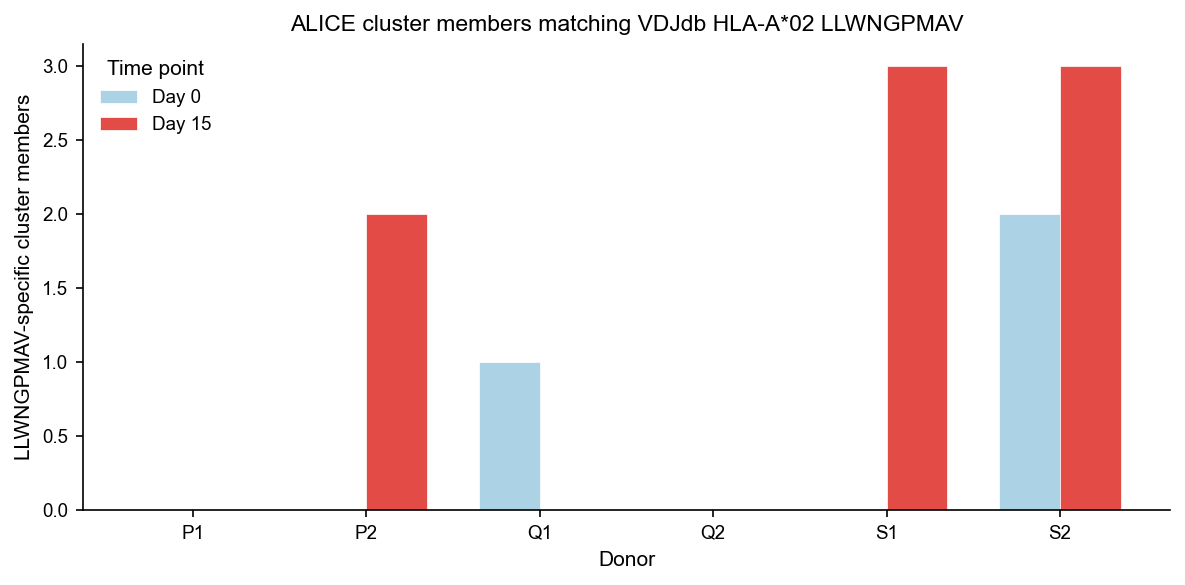

In [5]:
"""Cell 5: Intersect ALICE cluster members with VDJdb HLA-A*02 LLWNGPMAV reference."""

vdjdb_llw = load_vdjdb_latest(
    epitope="LLWNGPMAV", locus="TRB", species="HomoSapiens", mhc_a_contains="A*02",
)
llw_cdr3s = {c.junction_aa for c in vdjdb_llw.clonotypes if c.junction_aa}
print(f"VDJdb A*02 LLW reference: {len(llw_cdr3s)} unique CDR3 sequences")

llw_rows = []
for (donor, day), tbl in sorted(yf_alice_tables.items()):
    hits = tbl[(tbl["n_neighbors"] >= N_MIN_NEIGHBORS) & (tbl["q_value"] < FDR_THRESH)].copy()
    n_llw = hits["junction_aa"].isin(llw_cdr3s).sum() if not hits.empty else 0
    llw_rows.append({"Donor": donor, "Day": day, "LLW cluster hits": n_llw})

df_llw = pd.DataFrame(llw_rows).sort_values(["Donor", "Day"]).reset_index(drop=True)
display(
    df_llw.style
    .format({"LLW cluster hits": "{:,}"})
    .background_gradient(subset=["LLW cluster hits"], cmap="YlOrRd")
    .set_caption("ALICE hits matching HLA-A*02 LLWNGPMAV (VDJdb)")
    .set_table_styles([{"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "10pt")]}])
)

# Bar chart of LLW-specific ALICE hits per donor
fig, ax = plt.subplots(figsize=(8, 4))
for i, day in enumerate(days_ordered):
    sub = df_llw[df_llw["Day"] == day].set_index("Donor")
    heights = [sub.loc[d, "LLW cluster hits"] if d in sub.index else 0 for d in donors_ordered]
    offset = (i - len(days_ordered) / 2 + 0.5) * bar_width
    ax.bar(
        x + offset, heights, bar_width,
        color=day_colors[day], label=f"Day {day}",
        alpha=0.85, edgecolor="white", linewidth=0.4,
    )
ax.set_xticks(x)
ax.set_xticklabels(donors_ordered)
ax.set_xlabel("Donor")
ax.set_ylabel("LLWNGPMAV-specific cluster members")
ax.set_title("ALICE cluster members matching VDJdb HLA-A*02 LLWNGPMAV")
ax.legend(title="Time point", frameon=False)
plt.tight_layout()
plt.savefig("yf_llw_hits.pdf", bbox_inches="tight")
plt.show()


# Ankylosing Spondylitis (AS) Dataset

## Parse AS samples

Four donors from synovial fluid CD8+ TRB repertoires.
Donor B27 status metadata is hard-coded from study design.

In [6]:
"""Cell 6: Parse AS samples."""

AS_DONOR_META = {
    1: "B27_pos",
    2: "B27_pos",
    3: "B27_neg",
    4: "B27_pos",
}

as_samples: dict[int, LocusRepertoire] = {}

for donor_id, b27 in sorted(AS_DONOR_META.items()):
    pattern = f"Donor{donor_id}_B27_{b27}_SF_CD8.tsv.gz"
    fp = AS_DIR / pattern
    if not fp.exists():
        # Try globbing in case of slight filename variation.
        candidates = list(AS_DIR.glob(f"Donor{donor_id}_*.tsv.gz"))
        if not candidates:
            print(f"  WARNING: no file for Donor {donor_id} — skipping")
            continue
        fp = candidates[0]

    clonotypes = parser_yf.parse(str(fp))
    trb = [c for c in clonotypes if c.locus == "TRB"]
    rep = filter_functional(LocusRepertoire(clonotypes=trb, locus="TRB", repertoire_id=fp.stem))
    as_samples[donor_id] = rep
    print(f"  Donor {donor_id} ({b27}): {rep.clonotype_count:,} TRB clonotypes  [{fp.name}]")

print(f"\nLoaded {len(as_samples)} AS samples")

  Donor 1 (B27_pos): 29,193 TRB clonotypes  [Donor1_B27_pos_SF_CD8.tsv.gz]
  Donor 2 (B27_pos): 9,571 TRB clonotypes  [Donor2_B27_pos_SF_CD8.tsv.gz]
  Donor 3 (B27_neg): 38,404 TRB clonotypes  [Donor3_B27_neg_SF_CD8.tsv.gz]
  Donor 4 (B27_pos): 27,145 TRB clonotypes  [Donor4_B27_pos_SF_CD8.tsv.gz]

Loaded 4 AS samples


## Run ALICE on AS samples

Same parameters as YF (`match_mode="vj"`, `pgen_mode=ALICE_PGEN_MODE`, BH-FDR < 0.05).
B27\+ donors (1, 2, 4) are expected to share convergent CDR3 neighbourhoods absent in the B27\- donor (3) — driven by shared HLA-B27-restricted antigen responses in synovial tissue.

In [7]:
"""Cell 7: Run ALICE on AS samples; collect cluster members."""

as_alice_hits: dict[int, pd.DataFrame] = {}
as_alice_rows = []

for donor_id, rep in sorted(as_samples.items()):
    b27 = AS_DONOR_META[donor_id]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        result = compute_alice(
            rep,
            species="human",
            match_mode="vj",
            pgen_mode=ALICE_PGEN_MODE,
            as_table=True,
            n_jobs=N_JOBS,
        )

    tbl = result.table.to_pandas()
    hits = tbl[(tbl["n_neighbors"] >= N_MIN_NEIGHBORS) & (tbl["q_value"] < FDR_THRESH)].copy()
    hits["donor_id"] = donor_id
    hits["b27"] = b27
    as_alice_hits[donor_id] = hits
    as_alice_rows.append({
        "Donor": donor_id,
        "B27 status": b27,
        "Clonotypes": rep.clonotype_count,
        "ALICE clusters": len(hits),
        "Cluster %": 100 * len(hits) / max(1, rep.clonotype_count),
    })
    print(f"  Donor {donor_id} ({b27}): {rep.clonotype_count:,} clonotypes → {len(hits)} ALICE cluster members")

df_as_summary = pd.DataFrame(as_alice_rows)
display(
    df_as_summary.style
    .format({"Cluster %": "{:.1f}%", "Clonotypes": "{:,}", "ALICE clusters": "{:,}"})
    .background_gradient(subset=["Cluster %"], cmap="YlOrRd")
    .set_caption("AS — ALICE cluster members per donor (n_neighbors ≥ 2, BH-FDR < 0.05)")
    .set_table_styles([{"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "10pt")]}])
)

df_as_all_hits = pd.concat(as_alice_hits.values(), ignore_index=True)
print(f"\nTotal AS ALICE cluster members: {len(df_as_all_hits)}")
print(f"Unique junction_aa: {df_as_all_hits['junction_aa'].nunique()}")


  Donor 1 (B27_pos): 29,193 clonotypes → 2616 ALICE cluster members
  Donor 2 (B27_pos): 9,571 clonotypes → 726 ALICE cluster members
  Donor 3 (B27_neg): 38,404 clonotypes → 3600 ALICE cluster members
  Donor 4 (B27_pos): 27,145 clonotypes → 2834 ALICE cluster members


,Donor,B27 status,Clonotypes,ALICE clusters,Cluster %
0,1,B27_pos,"29,193","2,616",9.0%
1,2,B27_pos,"9,571",726,7.6%
2,3,B27_neg,"38,404","3,600",9.4%
3,4,B27_pos,"27,145","2,834",10.4%



Total AS ALICE cluster members: 9776
Unique junction_aa: 7826


## Build Hamming clonotype graph for AS ALICE hits

Each ALICE hit clonotype becomes a graph node. Edges connect pairs with Hamming distance ≤ 1 in the same V-gene.
We then build node color arrays for rendering with donor-specific colors.

In [8]:
"""Cell 8: Build Hamming distance graph for AS ALICE hits."""

# ── Donor color palette ────────────────────────────────────────────────────────
DONOR_COLORS = {
    1: "#f97f31",   # orange — B27_pos
    2: "#3182bd",   # blue   — B27_pos
    3: "#31a354",   # green  — B27_neg
    4: "#de2d26",   # red    — B27_pos
}

# Highlight clonotypes of special interest (TRBV9 pair from literature).
HIGHLIGHT_CLONOTYPES = {
    ("TRBV9", "CASSVGLFSTDTQYF", "TRBJ2-3"),
    ("TRBV9", "CASSVGLYSTDTQYF", "TRBJ2-3"),
}

def _as_clonotype(row: pd.Series) -> Clonotype:
    """Construct a Clonotype from a hits-table row."""
    return Clonotype(
        junction_aa=row.get("junction_aa") or "",
        v_gene=row.get("v_gene") or "",
        j_gene=row.get("j_gene") or "",
        duplicate_count=1,
        locus="TRB",
    )

# For visualization, limit each donor to the top MAX_VIZ_HITS_PER_DONOR most
# significant hits to keep the graph ≤ ~1000 nodes and layout tractable.
MAX_VIZ_HITS_PER_DONOR = 250

viz_hits: dict[int, pd.DataFrame] = {}
for donor_id, hits in sorted(as_alice_hits.items()):
    if len(hits) > MAX_VIZ_HITS_PER_DONOR:
        viz_hits[donor_id] = hits.nsmallest(MAX_VIZ_HITS_PER_DONOR, "p_value").copy()
    else:
        viz_hits[donor_id] = hits.copy()

# Build a list of Clonotype objects keeping track of which donor each belongs to.
clonotype_list = []
clonotype_donor_ids = []

for donor_id, hits in sorted(viz_hits.items()):
    for _, row in hits.iterrows():
        clon = _as_clonotype(row)
        clonotype_list.append(clon)
        clonotype_donor_ids.append(donor_id)

print(f"Visualization: {len(clonotype_list)} nodes (top {MAX_VIZ_HITS_PER_DONOR} per donor by p_value)")
print(f"Full ALICE hit counts: {', '.join(f'Donor {d}: {len(h)}' for d, h in sorted(as_alice_hits.items()))}")

# Build the edit-distance graph.
# v_gene_match=True: only edges between clonotypes sharing the same V gene.
g = build_edit_distance_graph(
    clonotype_list,
    metric="hamming",
    threshold=1,
    v_gene_match=True,
    n_jobs=N_JOBS,
)
g.vs["donor_id"] = clonotype_donor_ids

print(f"Graph: {g.vcount()} nodes, {g.ecount()} edges")

Visualization: 1000 nodes (top 250 per donor by p_value)
Full ALICE hit counts: Donor 1: 2616, Donor 2: 726, Donor 3: 3600, Donor 4: 2834
Graph: 1000 nodes, 4511 edges


## Render AS graph with donor colors and highlighted targets

Rendering strategy:
- Compute Fruchterman-Reingold layout
- Draw edges (thin grey lines)
- Single-donor nodes: filled circle with donor color
- Multi-donor nodes: pie-chart wedges per donor
- Star markers on target clonotypes

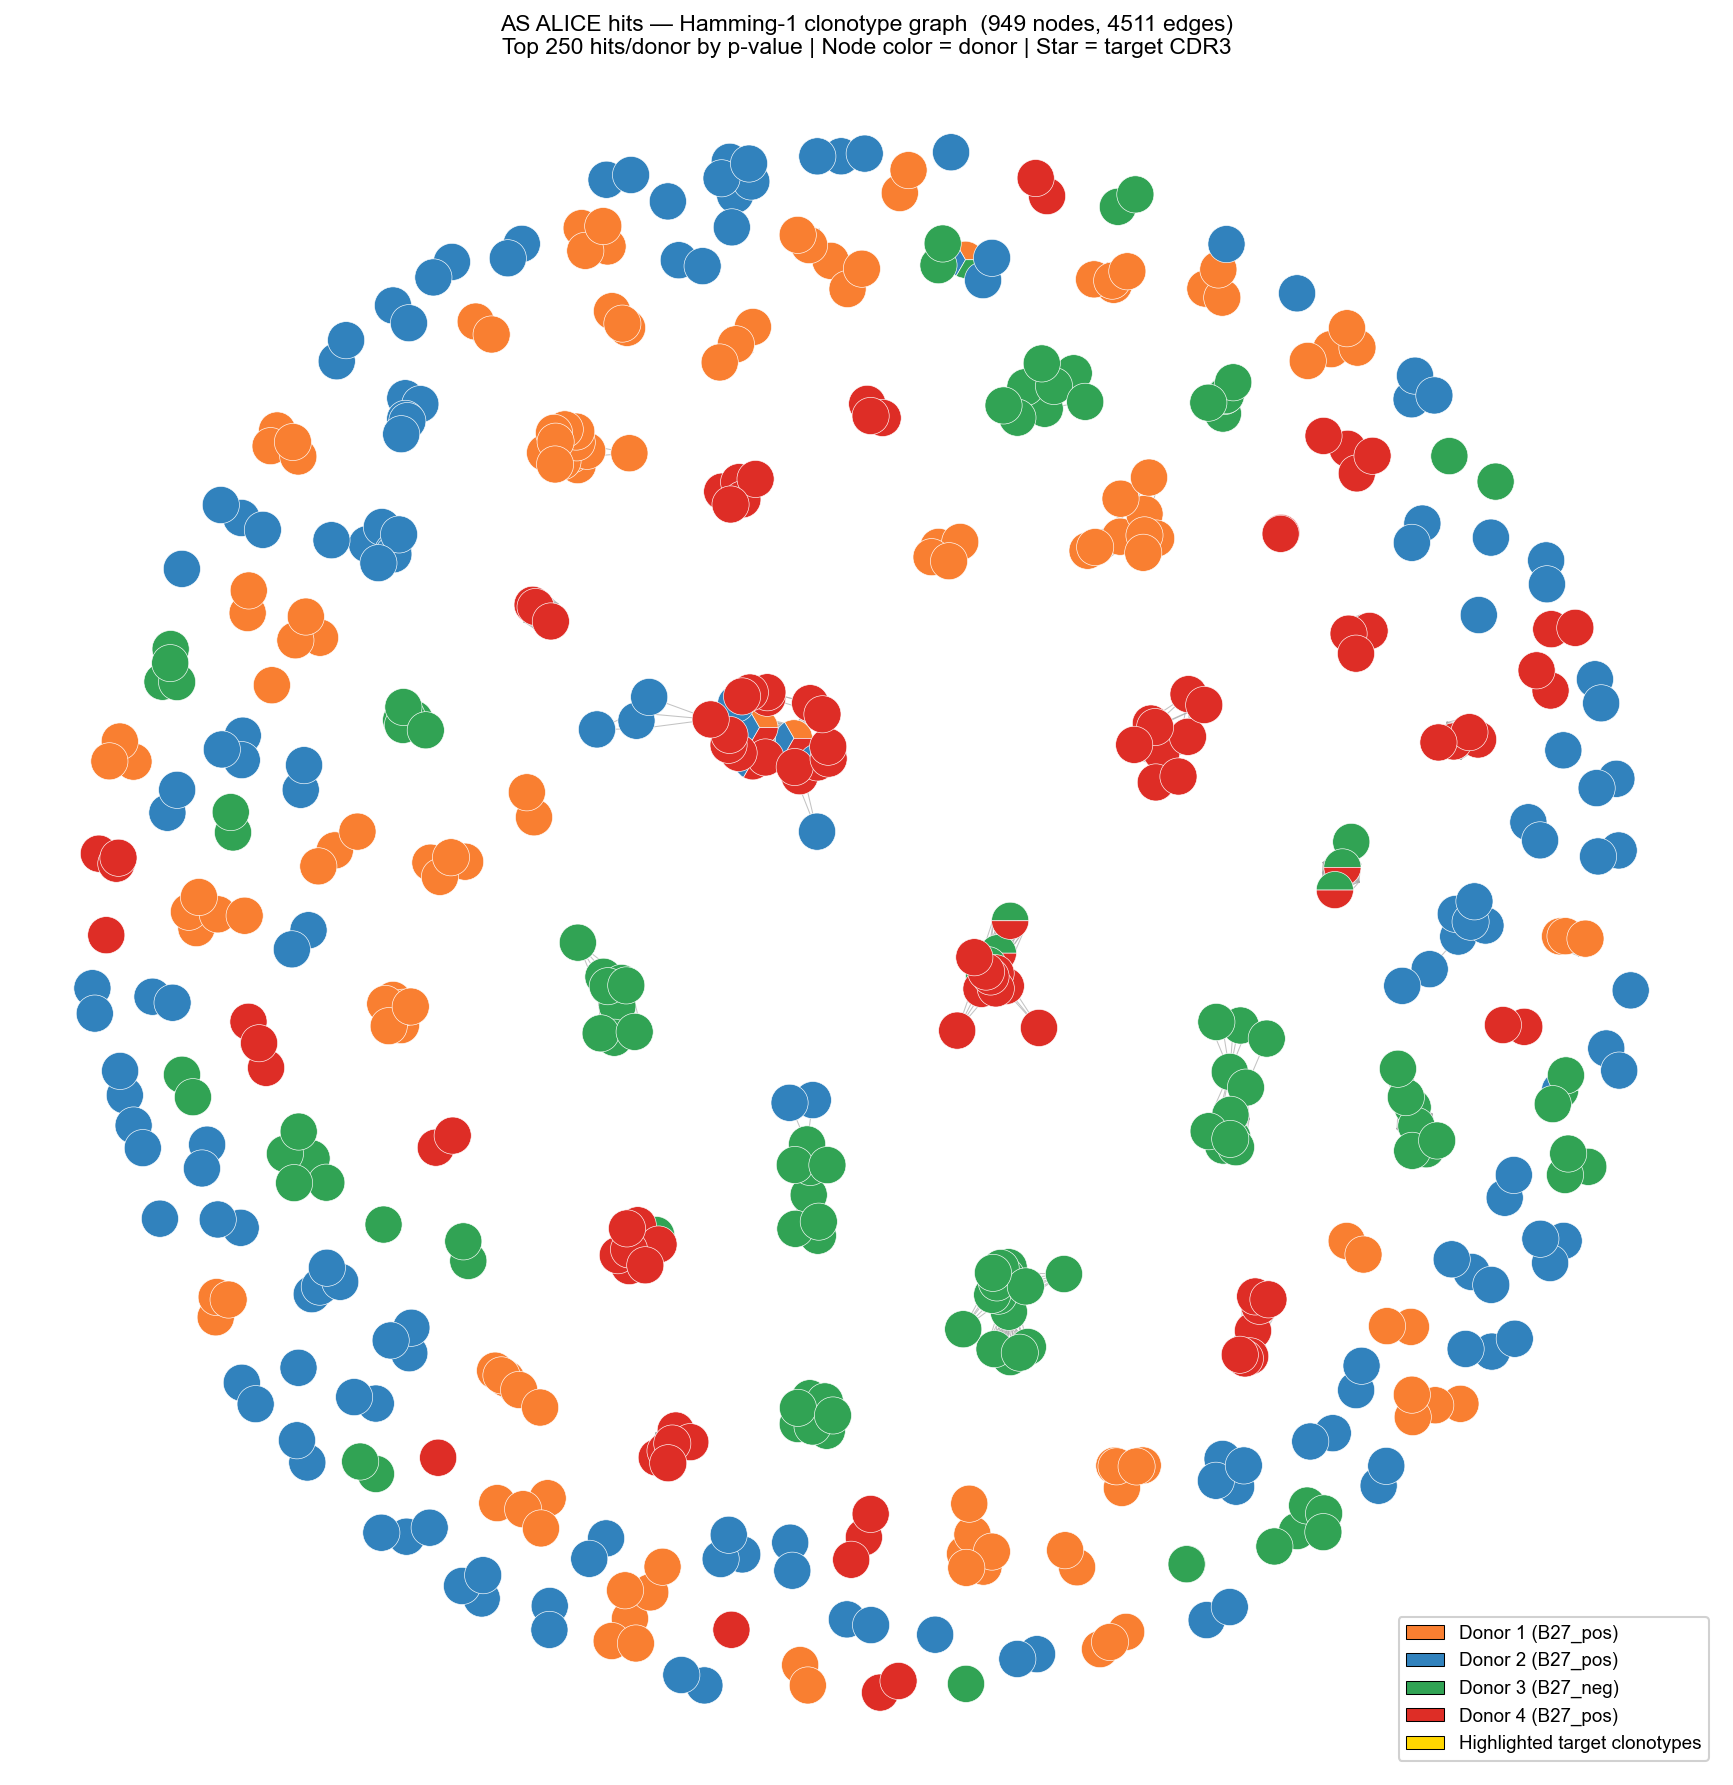

In [9]:
"""Cell 9: Render AS Hamming graph with donor-color pie nodes and highlighted targets."""
import igraph as ig
import matplotlib.colors as mc
from matplotlib.patches import Circle, FancyArrowPatch, Wedge

# ── Layout ─────────────────────────────────────────────────────────────────────
# Keep only nodes in connected components with ≥ 2 nodes for clarity.
comp_sizes = g.connected_components().sizes()
subg = g  # default: full graph
if max(comp_sizes) > 1:
    large_comps = [i for i, sz in enumerate(comp_sizes) if sz >= 2]
    keep = [v for v in range(g.vcount()) if g.connected_components().membership[v] in large_comps]
    if keep:
        subg = g.induced_subgraph(keep)

if subg.vcount() == 0:
    print("No connected components with ≥ 2 nodes. Skipping graph visualization.")
else:
    layout = subg.layout("fr", niter=500)
    coords = np.array(layout.coords)

    # Normalise coordinates to [0, 1] for matplotlib.
    if coords.shape[0] > 0:
        mn = coords.min(axis=0)
        mx = coords.max(axis=0)
        span = np.where(mx - mn > 0, mx - mn, 1.0)
        coords = (coords - mn) / span

    NODE_RADIUS = 0.012
    HIGHLIGHT_RADIUS = NODE_RADIUS * 1.5

    fig, ax = plt.subplots(figsize=(14, 12))
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_xlim(-0.05, 1.05)
    ax.set_ylim(-0.05, 1.05)

    # ── Draw edges ─────────────────────────────────────────────────────────────
    for e in subg.es:
        s, t = e.source, e.target
        xs = [coords[s, 0], coords[t, 0]]
        ys = [coords[s, 1], coords[t, 1]]
        ax.plot(xs, ys, color="#aaaaaa", linewidth=0.5, zorder=1, alpha=0.7)

    # ── Group vertices by CDR3+V to find multi-donor nodes ─────────────────────
    vertex_key = [
        (subg.vs[v]["name"], subg.vs[v]["v_gene"])
        for v in range(subg.vcount())
    ]
    # Map each node to the set of donor_ids that contributed it.
    key_to_nodes: dict[tuple, list[int]] = defaultdict(list)
    for v, key in enumerate(vertex_key):
        key_to_nodes[key].append(v)

    # igraph Vertex attribute access: use vertex["attr"] not vertex.get("attr")
    j_gene_in_graph = "j_gene" in subg.vs.attributes()

    # ── Draw nodes ─────────────────────────────────────────────────────────────
    drawn_nodes: set[int] = set()

    for key, node_ids in key_to_nodes.items():
        # Collect all donor_ids for this CDR3+V.
        donors_here = sorted({subg.vs[v]["donor_id"] for v in node_ids})
        # Representative position: mean of all duplicated node positions.
        pos = coords[node_ids, :].mean(axis=0)
        cx, cy = pos[0], pos[1]

        # Detect highlighted clonotypes.
        jaa = key[0]
        vgene = key[1]
        # Access j_gene attribute via igraph dict-style access.
        jgene = ""
        if j_gene_in_graph:
            raw = subg.vs[node_ids[0]]["j_gene"]
            jgene = raw if raw is not None else ""
        is_highlight = (vgene, jaa, jgene) in HIGHLIGHT_CLONOTYPES
        radius = HIGHLIGHT_RADIUS if is_highlight else NODE_RADIUS

        if len(donors_here) == 1:
            # Single donor: solid circle.
            color = DONOR_COLORS.get(donors_here[0], "#cccccc")
            circle = Circle(
                (cx, cy), radius,
                facecolor=color, edgecolor="black" if is_highlight else "white",
                linewidth=2.0 if is_highlight else 0.3,
                zorder=3,
            )
            ax.add_patch(circle)
        else:
            # Multi-donor: pie-chart wedges.
            n_d = len(donors_here)
            angle_per = 360.0 / n_d
            for k, did in enumerate(donors_here):
                wedge = Wedge(
                    (cx, cy), radius,
                    theta1=k * angle_per, theta2=(k + 1) * angle_per,
                    facecolor=DONOR_COLORS.get(did, "#cccccc"),
                    edgecolor="black" if is_highlight else "white",
                    linewidth=2.0 if is_highlight else 0.3,
                    zorder=3,
                )
                ax.add_patch(wedge)

        if is_highlight:
            ax.plot(
                cx, cy, marker="*", color="gold", markersize=10, zorder=5,
                markeredgecolor="black", markeredgewidth=0.5,
            )
            ax.annotate(
                jaa, (cx, cy + radius + 0.015),
                fontsize=6.5, ha="center", va="bottom", zorder=6,
                bbox=dict(boxstyle="round,pad=0.2", facecolor="lightyellow", alpha=0.85, edgecolor="grey"),
            )

        drawn_nodes.update(node_ids)

    # ── Legend ─────────────────────────────────────────────────────────────────
    legend_handles = [
        mpatches.Patch(facecolor=DONOR_COLORS[did], edgecolor="black", linewidth=0.5,
                       label=f"Donor {did} ({AS_DONOR_META[did]})")
        for did in sorted(DONOR_COLORS)
    ]
    legend_handles.append(mpatches.Patch(facecolor="gold", edgecolor="black", linewidth=0.5,
                                          label="Highlighted target clonotypes"))
    ax.legend(handles=legend_handles, loc="lower right", fontsize=9, framealpha=0.9)

    ax.set_title(
        f"AS ALICE hits — Hamming-1 clonotype graph  ({subg.vcount()} nodes, {subg.ecount()} edges)\n"
        f"Top {MAX_VIZ_HITS_PER_DONOR} hits/donor by p-value | Node color = donor | Star = target CDR3",
        fontsize=11,
    )
    plt.tight_layout()
    plt.savefig("as_alice_graph.pdf", bbox_inches="tight")
plt.show()

# Mixed Lymphocyte Reaction (MLR) Dataset

## Load Adaptive files and build TRB repertoires

The parser maps the Adaptive columns to AIRR-style fields. Files are parsed into single-locus TRB repertoires.
Gene names are normalized (e.g. `TCRBV01` → `TRBV1`).

In [10]:
"""Cell 10: Parse MLR samples from Adaptive immunoSEQ files."""
import importlib

import mir.common.parser as parser_module
parser_module = importlib.reload(parser_module)
AdaptiveParser = parser_module.AdaptiveParser
parser_adaptive = AdaptiveParser(locus="TRB")

def parse_mlr_filename(path: Path) -> dict[str, object]:
    """Return sample metadata encoded in the MLR filename."""
    stem = path.name
    stem = stem.removesuffix(".tsv.gz")
    stem = stem.removesuffix(".tsv")
    parts = stem.split("_")
    if "Fresh" in parts:
        condition = "fresh"
        idx = parts.index("Fresh")
    elif "Proliferating" in parts:
        condition = "proliferating"
        idx = parts.index("Proliferating")
    else:
        raise ValueError(f"Could not infer condition from {path.name}")

    sample_group = "_".join(parts[:idx])
    replicate = int(parts[-1])
    return {
        "sample_id": stem,
        "sample_group": sample_group,
        "condition": condition,
        "replicate": replicate,
    }

mlr_files = sorted(fp for fp in MLR_DIR.glob("*.tsv.gz") if "Stimulator" not in fp.name)
print(f"Found {len(mlr_files)} MLR files")

mlr_samples: dict[str, object] = {}
mlr_rows: list[dict[str, object]] = []

# Cap each MLR sample to the top MAX_CLONOTYPES most abundant clonotypes.
# Adaptive immunoSEQ data has millions of reads; downsampling by total reads
# produces too few unique CDR3s. Top-K by duplicate_count preserves the most
# abundant (and biologically informative) clonotypes for ALICE analysis.
MAX_CLONOTYPES = 5_000

for fp in mlr_files:
    meta = parse_mlr_filename(fp)
    rep = parser_adaptive.parse_file(fp, sample_id=str(meta["sample_id"]), locus="TRB")

    # Filter for functional clonotypes only.
    rep_functional = rep.subsample_functional()

    # Take the top MAX_CLONOTYPES by duplicate_count.
    if rep_functional.clonotype_count > MAX_CLONOTYPES:
        sorted_clones = sorted(
            rep_functional.clonotypes,
            key=lambda c: int(c.duplicate_count or 0),
            reverse=True,
        )[:MAX_CLONOTYPES]
        rep_downsampled = LocusRepertoire(
            sorted_clones,
            locus=rep_functional.locus,
            repertoire_metadata=dict(rep_functional.repertoire_metadata),
        )
    else:
        rep_downsampled = LocusRepertoire(
            list(rep_functional.clonotypes),
            locus=rep_functional.locus,
            repertoire_metadata=dict(rep_functional.repertoire_metadata),
        )

    rep_downsampled.repertoire_metadata.update(meta)
    mlr_samples[str(meta["sample_id"])] = rep_downsampled
    mlr_rows.append({
        **meta,
        "n_clonotypes_total": rep.clonotype_count,
        "n_clonotypes_functional": rep_functional.clonotype_count,
        "n_clonotypes": rep_downsampled.clonotype_count,
        "n_duplicates_total": rep.duplicate_count,
        "n_duplicates_functional": rep_functional.duplicate_count,
        "n_duplicates": rep_downsampled.duplicate_count,
    })
    print(
        f"  {fp.name}: {rep.clonotype_count:,} → {rep_functional.clonotype_count:,} functional "
        f"→ {rep_downsampled.clonotype_count:,} top-{MAX_CLONOTYPES} for ALICE"
    )

df_mlr_samples = pd.DataFrame(mlr_rows).sort_values(["sample_group", "condition", "replicate"])
df_mlr_samples = df_mlr_samples.reset_index(drop=True)
display(df_mlr_samples)

Found 24 MLR files
  MLR7_TCR1_Fresh_1.tsv.gz: 562,409 → 511,800 functional → 5,000 top-5000 for ALICE
  MLR7_TCR1_Fresh_2.tsv.gz: 448,953 → 410,592 functional → 5,000 top-5000 for ALICE
  MLR7_TCR1_Proliferating_1.tsv.gz: 45,698 → 40,301 functional → 5,000 top-5000 for ALICE
  MLR7_TCR1_Proliferating_2.tsv.gz: 45,971 → 40,405 functional → 5,000 top-5000 for ALICE
  MLR8_TCR2_Fresh_1.tsv.gz: 848,893 → 774,386 functional → 5,000 top-5000 for ALICE
  MLR8_TCR2_Fresh_2.tsv.gz: 945,294 → 860,876 functional → 5,000 top-5000 for ALICE
  MLR8_TCR2_Proliferating_1.tsv.gz: 104,389 → 93,251 functional → 5,000 top-5000 for ALICE
  MLR8_TCR2_Proliferating_2.tsv.gz: 88,868 → 79,518 functional → 5,000 top-5000 for ALICE
  MLR9_TCR3_Fresh_1.tsv.gz: 706,881 → 648,207 functional → 5,000 top-5000 for ALICE
  MLR9_TCR3_Fresh_2.tsv.gz: 578,431 → 530,119 functional → 5,000 top-5000 for ALICE
  MLR9_TCR3_Proliferating_1.tsv.gz: 76,291 → 68,522 functional → 5,000 top-5000 for ALICE
  MLR9_TCR3_Proliferating_

,sample_id,sample_group,condition,replicate,n_clonotypes_total,n_clonotypes_functional,n_clonotypes,n_duplicates_total,n_duplicates_functional,n_duplicates
0,MLR7_TCR1_Fresh_1,MLR7_TCR1,fresh,1,562409,511800,5000,39060366,36224747,18594465
1,MLR7_TCR1_Fresh_2,MLR7_TCR1,fresh,2,448953,410592,5000,14774134,13702917,7224562
2,MLR7_TCR1_Proliferating_1,MLR7_TCR1,proliferating,1,45698,40301,5000,28247803,26145533,22533705
3,MLR7_TCR1_Proliferating_2,MLR7_TCR1,proliferating,2,45971,40405,5000,31989495,29412778,25511721
4,MLR8_TCR2_Fresh_1,MLR8_TCR2,fresh,1,848893,774386,5000,21189395,19476323,6067168
5,MLR8_TCR2_Fresh_2,MLR8_TCR2,fresh,2,945294,860876,5000,32165682,29545743,9049838
6,MLR8_TCR2_Proliferating_1,MLR8_TCR2,proliferating,1,104389,93251,5000,31406916,27112376,18854292
7,MLR8_TCR2_Proliferating_2,MLR8_TCR2,proliferating,2,88868,79518,5000,17719903,15213872,11102431
8,MLR9_TCR3_Fresh_1,MLR9_TCR3,fresh,1,706881,648207,5000,20815699,19383488,6895071
9,MLR9_TCR3_Fresh_2,MLR9_TCR3,fresh,2,578431,530119,5000,17854323,16633539,5917578


## Run ALICE on all MLR samples

ALICE is run with `match_mode="vj"` conditioned on both V and J gene usage.
The primary metric is **cluster member fraction**: the proportion of CDR3s with at least one Hamming-1 neighbour in the same repertoire that passes BH-FDR.

Hypothesis: **proliferating > fresh** — antigen-driven alloresponse produces convergent CDR3 clusters absent in naive/unstimulated repertoires.

In [11]:
"""Cell 11: Run ALICE on all MLR samples; collect cluster member fractions."""

mlr_alice_tables: dict[str, pd.DataFrame] = {}
mlr_alice_rows = []

for sample_id, rep in sorted(mlr_samples.items()):
    meta = rep.repertoire_metadata
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        result = compute_alice(
            rep,
            species="human",
            match_mode="vj",
            pgen_mode=ALICE_PGEN_MODE,
            as_table=True,
            n_jobs=N_JOBS,
        )

    tbl = result.table.to_pandas()
    mlr_alice_tables[sample_id] = tbl
    hits = tbl[(tbl["n_neighbors"] >= N_MIN_NEIGHBORS) & (tbl["q_value"] < FDR_THRESH)].copy()

    mlr_alice_rows.append({
        "sample_id": sample_id,
        "sample_group": meta.get("sample_group", ""),
        "condition": meta.get("condition", ""),
        "replicate": meta.get("replicate", ""),
        "n_clonotypes": rep.clonotype_count,
        "n_cluster_members": len(hits),
        "cluster_fraction": len(hits) / max(1, rep.clonotype_count),
    })
    print(
        f"  {sample_id}: {rep.clonotype_count:,} clonotypes → "
        f"{len(hits)} ALICE cluster members ({100*len(hits)/rep.clonotype_count:.1f}%)"
    )

df_mlr_alice = pd.DataFrame(mlr_alice_rows).sort_values(
    ["condition", "sample_group", "replicate"]
).reset_index(drop=True)

# Summary by condition
df_cond_summary = (
    df_mlr_alice.groupby("condition")["cluster_fraction"]
    .agg(["mean", "std", "min", "max", "count"])
    .rename(columns={"mean": "Mean", "std": "SD", "min": "Min", "max": "Max", "count": "N"})
    .reset_index()
)
display(
    df_cond_summary.style
    .format({"Mean": "{:.4f}", "SD": "{:.4f}", "Min": "{:.4f}", "Max": "{:.4f}"})
    .background_gradient(subset=["Mean"], cmap="YlOrRd")
    .set_caption("MLR — cluster member fraction by condition")
    .set_table_styles([{"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "10pt")]}])
)


  MLR7_TCR1_Fresh_1: 5,000 clonotypes → 208 ALICE cluster members (4.2%)
  MLR7_TCR1_Fresh_2: 5,000 clonotypes → 191 ALICE cluster members (3.8%)
  MLR7_TCR1_Proliferating_1: 5,000 clonotypes → 212 ALICE cluster members (4.2%)
  MLR7_TCR1_Proliferating_2: 5,000 clonotypes → 214 ALICE cluster members (4.3%)
  MLR8_TCR2_Fresh_1: 5,000 clonotypes → 251 ALICE cluster members (5.0%)
  MLR8_TCR2_Fresh_2: 5,000 clonotypes → 268 ALICE cluster members (5.4%)
  MLR8_TCR2_Proliferating_1: 5,000 clonotypes → 159 ALICE cluster members (3.2%)
  MLR8_TCR2_Proliferating_2: 5,000 clonotypes → 149 ALICE cluster members (3.0%)
  MLR9_TCR3_Fresh_1: 5,000 clonotypes → 164 ALICE cluster members (3.3%)
  MLR9_TCR3_Fresh_2: 5,000 clonotypes → 181 ALICE cluster members (3.6%)
  MLR9_TCR3_Proliferating_1: 5,000 clonotypes → 171 ALICE cluster members (3.4%)
  MLR9_TCR3_Proliferating_2: 5,000 clonotypes → 136 ALICE cluster members (2.7%)
  TCR4_Fresh_Responder_R_1: 5,000 clonotypes → 192 ALICE cluster members (3.

,condition,Mean,SD,Min,Max,N
0,fresh,0.0440,0.0114,0.0328,0.0670,12
1,proliferating,0.0408,0.0084,0.0272,0.0540,12


## Fresh vs Proliferating: ALICE cluster fraction

Boxplot with individual sample overlay comparing **cluster member fraction** between fresh and proliferating conditions.
A one-sided Mann-Whitney U test assesses whether proliferating samples have significantly higher cluster fractions (greater convergent CDR3 usage).

In [ ]:
"""Cell 12: Fresh vs Proliferating — boxplot + Mann-Whitney U on cluster fraction."""

fresh_cf = df_mlr_alice[df_mlr_alice["condition"] == "fresh"]["cluster_fraction"].values
prolif_cf = df_mlr_alice[df_mlr_alice["condition"] == "proliferating"]["cluster_fraction"].values

if len(fresh_cf) >= 2 and len(prolif_cf) >= 2:
    stat, pval = mannwhitneyu(prolif_cf, fresh_cf, alternative="greater")
    print(f"Mann-Whitney U (proliferating > fresh): U = {stat:.0f}, p = {pval:.4f}")
    sig_label = (
        "***" if pval < 0.001 else
        "**" if pval < 0.01 else
        "*" if pval < 0.05 else
        f"p = {pval:.3f}"
    )
else:
    pval, sig_label = float("nan"), "n.s."
    print("Too few samples for Mann-Whitney U test.")

conditions = ["fresh", "proliferating"]
condition_colors = {"fresh": "#9ecae1", "proliferating": "#de2d26"}
data_by_condition = [fresh_cf, prolif_cf]

fig, ax = plt.subplots(figsize=(5, 5))
bp = ax.boxplot(
    data_by_condition,
    tick_labels=conditions,
    patch_artist=True,
    showfliers=False,
    widths=0.45,
    boxprops=dict(linewidth=0.8),
    whiskerprops=dict(linewidth=0.8, linestyle="--"),
    capprops=dict(linewidth=0.8),
    medianprops=dict(linewidth=1.5, color="black"),
)
for patch, cond in zip(bp["boxes"], conditions):
    patch.set(facecolor=condition_colors[cond], alpha=0.75)

rng = np.random.default_rng(SEED)
for i, (cond, vals) in enumerate(zip(conditions, data_by_condition)):
    jitter = rng.uniform(-0.12, 0.12, size=len(vals))
    ax.scatter(
        np.full(len(vals), i + 1) + jitter, vals,
        color=condition_colors[cond], edgecolors="black",
        linewidths=0.5, s=30, zorder=3, alpha=0.9,
    )

# Significance bracket
y_max = max(np.max(fresh_cf), np.max(prolif_cf)) if len(fresh_cf) and len(prolif_cf) else 1.0
bracket_y = y_max * 1.08
ax.annotate(
    "", xy=(2, bracket_y), xytext=(1, bracket_y),
    arrowprops=dict(arrowstyle="-", color="black", lw=0.8),
)
ax.text(1.5, bracket_y * 1.01, sig_label, ha="center", va="bottom", fontsize=9)

ax.set_ylabel("ALICE cluster fraction")
ax.set_title("MLR: fresh vs proliferating\n(ALICE cluster members, BH-FDR < 0.05)")
plt.tight_layout()
plt.savefig("mlr_alice_cluster_fraction.pdf", bbox_inches="tight")
plt.show()


## Summary

This notebook analyses ALICE on three independent benchmark datasets:

1. **YF Dataset:** Yellow Fever vaccine response. ALICE cluster members are intersected with VDJdb LLWNGPMAV/HLA-A\*02 entries to validate antigen-specific signal at day 15.
2. **AS Dataset:** Ankylosing Spondylitis synovial TRB repertoires. Hamming-1 graph visualization highlights convergent CDR3 clusters shared across B27\+ donors.
3. **MLR Dataset:** Mixed lymphocyte reaction. ALICE cluster fraction is compared between fresh and proliferating conditions using a one-sided Mann-Whitney U test.

**Key methodological note:** ALICE cluster membership requires both `n_neighbors ≥ 2` (at least one real Hamming-1 neighbour exists in the repertoire) AND `q_value < 0.05` (BH-FDR). Without the neighbourhood filter, all unique CDR3s are Pgen-significant in small repertoires because their generation probability is far lower than 1/N, producing trivially small p-values.

**Reference:** Pogorelyy MV *et al.* PLoS Biol. 2019;17(6):e3000314. doi:10.1371/journal.pbio.3000314. PMID:31194732.